<a href="https://www.kaggle.com/code/mykolarekunenko/fork-of-notebook-hw-3?scriptVersionId=293493007" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

Завдання:
Ознайомитись з даними та структурою даних
Створіть доповнення(transform) для тренувальних та тестових даних. посилання
Створіть train_dataset та test_dataset за допомогою ImageFolder(папка train)
Переконайтесь що у вас привильні назви класів
Створіть DataLoader для тренувальних та тестових даних
Візуалізуйте дані
Збережіть kaggle notebook для подальшої роботи

In [37]:
import torch  
from torchvision import datasets, transforms 

In [38]:
data_dir = "/kaggle/input/fruit-recognition/train/train"
# Створюємо екземпляр ImageFolder
dataset = datasets.ImageFolder(data_dir)

In [39]:
dataset.classes

['Apple Braeburn',
 'Apple Granny Smith',
 'Apricot',
 'Avocado',
 'Banana',
 'Blueberry',
 'Cactus fruit',
 'Cantaloupe',
 'Cherry',
 'Clementine',
 'Corn',
 'Cucumber Ripe',
 'Grape Blue',
 'Kiwi',
 'Lemon',
 'Limes',
 'Mango',
 'Onion White',
 'Orange',
 'Papaya',
 'Passion Fruit',
 'Peach',
 'Pear',
 'Pepper Green',
 'Pepper Red',
 'Pineapple',
 'Plum',
 'Pomegranate',
 'Potato Red',
 'Raspberry',
 'Strawberry',
 'Tomato',
 'Watermelon']

In [40]:
data_train, data_test = torch.utils.data.random_split(dataset,[0.8, 0.2])

In [41]:
img, label = data_train[5000]

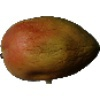

In [42]:
img

In [43]:
len(dataset), len(data_train), len(data_test)

(16854, 13484, 3370)

In [44]:
train_transform = transforms.Compose(
    [transforms.Resize([64, 64]),
     transforms.RandomRotation(180),
     transforms.RandomHorizontalFlip(p=0.5),
     transforms.RandomVerticalFlip(p=0.5),
     transforms.ToTensor()
    ] 
)

test_transform = transforms.Compose(
    [transforms.Resize([64, 64]),
     transforms.ToTensor()
    ] 
)

In [45]:
train_transform(img).shape

torch.Size([3, 64, 64])

In [46]:
test_transform(img).shape

torch.Size([3, 64, 64])

In [47]:
from torch.utils.data import Dataset, DataLoader

class TransformDataset(Dataset):
    def __init__(self, dataset, transformer):
        self.dataset = dataset
        self.transformer = transformer

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        img, label = self.dataset[idx]

        img_new = self.transformer(img)

        return img_new, label

In [48]:
train_data = TransformDataset(data_train, train_transform)
test_data = TransformDataset(data_test, test_transform)

In [49]:
train_loader = DataLoader(train_data, batch_size=256)
test_loader = DataLoader(test_data, batch_size=256)

In [50]:
for img,idx in test_loader:
     print(img.shape)
     print(idx.shape)

torch.Size([256, 3, 64, 64])
torch.Size([256])
torch.Size([256, 3, 64, 64])
torch.Size([256])
torch.Size([256, 3, 64, 64])
torch.Size([256])
torch.Size([256, 3, 64, 64])
torch.Size([256])
torch.Size([256, 3, 64, 64])
torch.Size([256])
torch.Size([256, 3, 64, 64])
torch.Size([256])
torch.Size([256, 3, 64, 64])
torch.Size([256])
torch.Size([256, 3, 64, 64])
torch.Size([256])
torch.Size([256, 3, 64, 64])
torch.Size([256])
torch.Size([256, 3, 64, 64])
torch.Size([256])
torch.Size([256, 3, 64, 64])
torch.Size([256])
torch.Size([256, 3, 64, 64])
torch.Size([256])
torch.Size([256, 3, 64, 64])
torch.Size([256])
torch.Size([42, 3, 64, 64])
torch.Size([42])


(64, 64, 3)


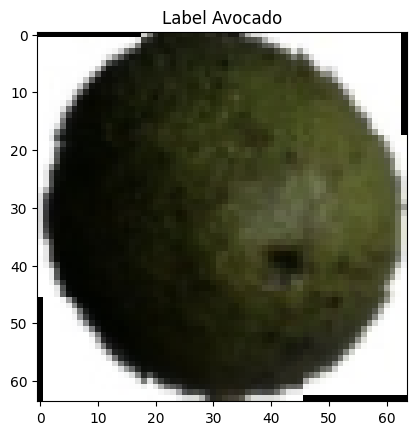

(64, 64, 3)


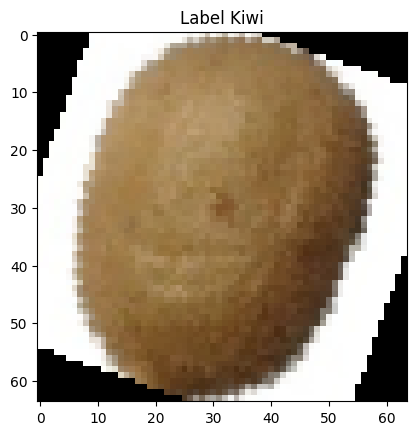

(64, 64, 3)


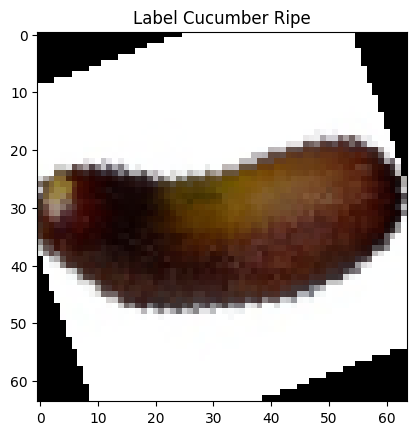

In [51]:
import matplotlib.pyplot as plt

for i in range(3):  # Show 3 images

    # Get the image data (tensor) and convert it back to a NumPy array for manipulation
    img, y = train_data[i]
    img = img.numpy()
    
    # Convert the color channels from (channels, height, width) to (height, width, channels) for pyplot
    img = img.transpose((1, 2, 0))
    print(img.shape)
    
    # Get the label name from the dataset class labels
    label = dataset.classes[y]

    # Plot the image with a title (including label name)
    plt.imshow(img)
    plt.title(f"Label {label}")
    plt.show()

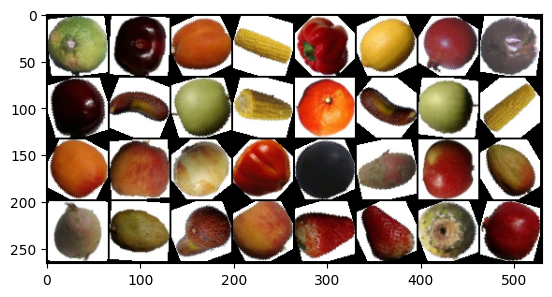

In [52]:
from torchvision.utils import make_grid

loader = torch.utils.data.DataLoader(train_data, shuffle=True, batch_size=32)

batch, labels = next(iter(loader))

grid = make_grid(batch).permute(1, 2, 0) # результатом є тензор

plt.imshow(grid)

In [53]:
img, label = train_data[0]

img.shape

torch.Size([3, 64, 64])

In [54]:
3*64*64

12288

In [55]:
len(dataset.classes)

33

In [56]:
from torch import nn

#нейромережа
model = nn.Sequential(
    nn.Flatten(),   # переведе зображення 3х64х64 в нейрони 12288
    nn.Linear(12288, 128),   # на вході 12288 нейронів передає інформацію 64 нейронам
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, 33)   # 33 нейрона на кожен тип фрукта
)


# підключення до процесора
device = 'cuda'
model = model.to(device)

In [57]:
img = img.unsqueeze(0).to(device)
result = model(img)
result

tensor([[-0.0920,  0.0253,  0.0209, -0.0259,  0.0928, -0.1006, -0.0734, -0.0393,
          0.0379, -0.1349, -0.0562, -0.1006,  0.0919,  0.1328, -0.0420, -0.1563,
         -0.1453,  0.1013,  0.0237,  0.0794, -0.1032, -0.1488,  0.0067,  0.0129,
          0.1114, -0.1181, -0.0836,  0.1833, -0.0289,  0.0064, -0.0373, -0.1167,
          0.0533]], device='cuda:0', grad_fn=<AddmmBackward0>)

In [58]:
#ймовірності
probs = nn.Softmax(dim=1)(result)
probs

# Або дивись найімовірніший клас:
predicted_class = probs.argmax(1).item()
confidence = probs.max().item() * 100

print(f"Прогноз: {dataset.classes[predicted_class]}")
print(f"Впевненість: {confidence:.2f}%")

print(f"\n🎯 Правильна відповідь: {dataset.classes[label]}")

if predicted_class == label:
    print("✅ ПРАВИЛЬНО!")
else:
    print("❌ ПОМИЛКА - модель ще не навчена")

Прогноз: Pomegranate
Впевненість: 3.69%


In [59]:
label

3

In [60]:
# Функція втрат для класифікації
loss_fn = nn.CrossEntropyLoss()

# Оптимізатор (Adam) для оновлення ваг моделі
optimizer = torch.optim.Adam(
    model.parameters(),   # параметри нефромережі
    lr=0.001
)

loss_list = []
loss_test_list = []
accuracy_train_list = []
accuracy_test_list = []   

for epoch in range(10):
    
    # ТРЕНУВАННЯ
    model.train()  
    for imgs, labels in train_loader:
        imgs = imgs.to(device)
        labels = labels.to(device)
        
        result = model(imgs)
        loss = loss_fn(result, labels)
        
        # НОВЕ: розрахунок точності
        correct = (result.argmax(1) == labels).sum().item()
        accuracy = correct / len(labels)
        accuracy_train_list.append(accuracy)
        
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        
        loss_list.append(loss.cpu().item())
    
    # ВАЛІДАЦІЯ (ЗМІНЕНО)
    model.eval()
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs = imgs.to(device)
            labels = labels.to(device)
            
            result = model(imgs)
            loss = loss_fn(result, labels)
            
            correct = (result.argmax(1) == labels).sum().item()
            accuracy = correct / len(labels)
            accuracy_test_list.append(accuracy)
            
            loss_test_list.append(loss.cpu().item())
    
    # НОВЕ: вивід статистики
    print(f"\nЕпоха {epoch+1}/10:")
    print(f"Train Accuracy: {sum(accuracy_train_list[-len(train_loader):])/len(train_loader):.2%}")
    print(f"Test Accuracy: {sum(accuracy_test_list[-len(test_loader):])/len(test_loader):.2%}")

# НОВЕ: збереження моделі
torch.save(model.state_dict(), 'fruit_model.pth')


Епоха 1/10:
Train Accuracy: 37.31%
Test Accuracy: 60.56%

Епоха 2/10:
Train Accuracy: 74.49%
Test Accuracy: 79.17%

Епоха 3/10:
Train Accuracy: 84.06%
Test Accuracy: 86.40%

Епоха 4/10:
Train Accuracy: 87.95%
Test Accuracy: 88.85%

Епоха 5/10:
Train Accuracy: 90.04%
Test Accuracy: 90.45%

Епоха 6/10:
Train Accuracy: 91.09%
Test Accuracy: 91.48%

Епоха 7/10:
Train Accuracy: 92.00%
Test Accuracy: 92.46%

Епоха 8/10:
Train Accuracy: 92.47%
Test Accuracy: 93.91%

Епоха 9/10:
Train Accuracy: 92.54%
Test Accuracy: 88.38%

Епоха 10/10:
Train Accuracy: 93.50%
Test Accuracy: 92.14%


In [65]:
correct_predictions = 0
total_predictions = 0

for imgs, labels in test_loader:
    imgs = imgs.to(device)
    predictions = model(imgs).argmax(1)
    
    correct_predictions += (predictions == labels.to(device)).sum().item()
    total_predictions += len(labels)

accuracy = correct_predictions / total_predictions * 100
print(f"Точність моделі: {accuracy:.2f}%")


Точність моделі: 92.55%


In [61]:
img, label = train_data[0]
img = img.unsqueeze(0)
img.shape
img = img.to(device)
prediction = model(img)

print(label)
print(nn.Softmax()(prediction))

3
tensor([[1.3541e-11, 7.3268e-06, 1.7962e-12, 9.9434e-01, 6.1181e-10, 1.9499e-10,
         1.7861e-05, 1.1188e-16, 5.0912e-05, 3.7058e-23, 7.2839e-17, 6.4319e-12,
         9.0444e-04, 5.8769e-07, 1.4019e-14, 4.2284e-07, 6.8317e-05, 2.7985e-15,
         3.0787e-08, 1.9383e-07, 2.4655e-12, 4.0979e-12, 5.0271e-13, 4.5769e-03,
         5.4586e-15, 1.1577e-06, 1.1157e-07, 6.1565e-11, 3.4665e-12, 7.3508e-15,
         1.7356e-08, 2.8771e-12, 2.8334e-05]], device='cuda:0',
       grad_fn=<SoftmaxBackward0>)


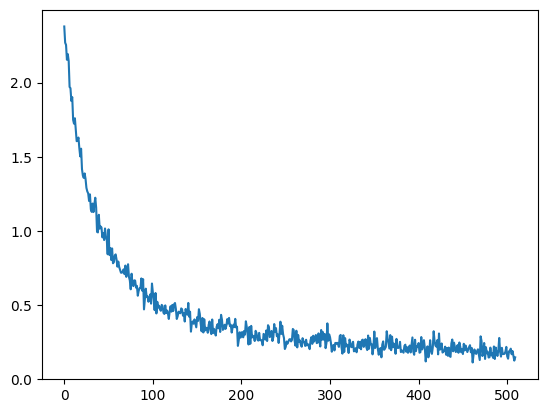

In [62]:
import matplotlib.pyplot as plt

new_list = loss_list[20:]
plt.plot(new_list)

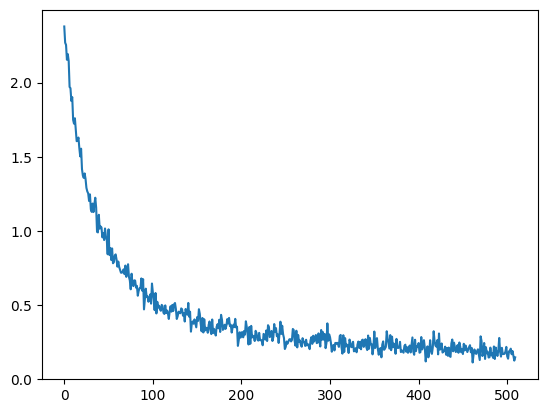

In [63]:
plt.plot(new_list)

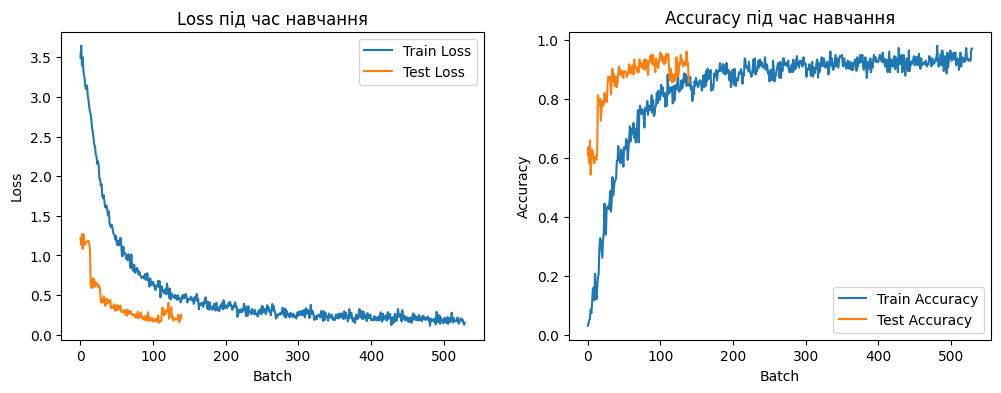

In [64]:
import matplotlib.pyplot as plt

# Графік loss
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(loss_list, label='Train Loss')
plt.plot(loss_test_list, label='Test Loss')
plt.xlabel('Batch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss під час навчання')

plt.subplot(1, 2, 2)
plt.plot(accuracy_train_list, label='Train Accuracy')
plt.plot(accuracy_test_list, label='Test Accuracy')
plt.xlabel('Batch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy під час навчання')

plt.show()
